# Exercício:

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto deve ter valores up e downregulated.

        Gene  Log2FoldChange
0  Gene_0542       -2.564853
1  Gene_0467        2.307083
2  Gene_0182        1.571421
3  Gene_0333        2.037902
4  Gene_0041        2.369233
       Log2FoldChange
count     1000.000000
mean         0.009666
std          2.053949
min         -3.348443
25%         -1.985681
50%         -0.152221
75%          2.006347
max          3.926366


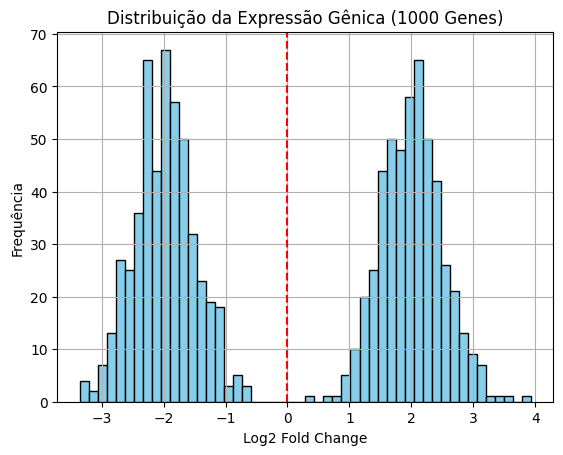

,Gene,Log2FoldChange
0,Gene_0542,-2.564853
1,Gene_0467,2.307083
2,Gene_0182,1.571421
3,Gene_0333,2.037902
4,Gene_0041,2.369233
...,...,...
995,Gene_0971,-1.935948
996,Gene_0872,-2.399149
997,Gene_0305,1.989549
998,Gene_0428,2.343026


In [7]:
import numpy as np
import pandas as pd

np.random.seed(42)

# gerar 500 genes UP-regulated (média positiva)
up_genes = np.random.normal(loc=2.0, scale=0.5, size=500)

# gerar 500 genes DOWN-regulated (média negativa)
down_genes = np.random.normal(loc=-2.0, scale=0.5, size=500)

# concatenar os dois conjuntos para formar os 1.000 genes
expressao_total = np.concatenate([up_genes, down_genes])

# geração de nomes para os genes e organizar em um DataFrame
nomes_genes = [f'Gene_{i+1:04d}' for i in range(1000)]
df_expressao = pd.DataFrame({
    'Gene': nomes_genes,
    'Log2FoldChange': expressao_total
})

# embaralhar os dados 
df_expressao = df_expressao.sample(frac=1).reset_index(drop=True)

print(df_expressao.head())
print(df_expressao.describe())

#fiz um gráfico também 
import matplotlib.pyplot as plt

df_expressao['Log2FoldChange'].hist(bins=50, color='skyblue', edgecolor='black')
plt.title('Distribuição da Expressão Gênica (1000 Genes)')
plt.xlabel('Log2 Fold Change')
plt.ylabel('Frequência')
plt.axvline(0, color='red', linestyle='--') # Linha divisória no zero
plt.show()
df_expressao

## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [ ]:
import numpy as np
import pandas as pd

# número de pacientes
n_pacientes = 1000

# supondo que, em cada paciente, entre 0 e 500 genes podem estar UP
contagem_up = np.random.randint(0, 501, size=n_pacientes)

# mesma coisa para os down
contagem_down = np.random.randint(0, 501, size=n_pacientes)

df_pacientes = pd.DataFrame({
    'Paciente_ID': [f'P_{i+1:04d}' for i in range(n_pacientes)],
    'Genes_Up': contagem_up,
    'Genes_Down': contagem_down
})

# coluna de "Total Diferencialmente Expressos"
df_pacientes['Total_DE'] = df_pacientes['Genes_Up'] + df_pacientes['Genes_Down']

print(df_pacientes.head())
df_pacientes

  Paciente_ID  Genes_Up  Genes_Down  Total_DE
0      P_0001       201         485       686
1      P_0002        16         265       281
2      P_0003       321         423       744
3      P_0004         5         127       132
4      P_0005        57         237       294


,Paciente_ID,Genes_Up,Genes_Down,Total_DE
0,P_0001,201,485,686
1,P_0002,16,265,281
2,P_0003,321,423,744
3,P_0004,5,127,132
4,P_0005,57,237,294
...,...,...,...,...
995,P_0996,301,105,406
996,P_0997,95,198,293
997,P_0998,189,385,574
998,P_0999,452,105,557


In [ ]:

import numpy as np

# expressão de 1000 genes (linhas) para 1000 pacientes (colunas) usando como base a média de expressão gerada no Ex 01 (expressao_total)
matriz_dados = np.array([np.random.normal(loc=val, scale=0.2, size=1000) for val in expressao_total])

df_matriz = pd.DataFrame(
    matriz_dados,
    index=[f'Gene_{i+1:04d}' for i in range(1000)],
    columns=[f'P_{i+1:04d}' for i in range(1000)]
)

df_matriz

,P_0001,P_0002,P_0003,P_0004,P_0005,P_0006,P_0007,P_0008,P_0009,P_0010,...,P_0991,P_0992,P_0993,P_0994,P_0995,P_0996,P_0997,P_0998,P_0999,P_1000
Gene_0001,2.044532,2.389060,2.838208,2.083901,2.347434,2.226439,2.482540,2.282863,1.949352,2.355258,...,2.627434,2.202556,2.230277,1.908291,2.221536,2.043634,2.276227,2.178212,2.072905,2.141783
Gene_0002,2.148692,2.071926,2.161425,1.671456,2.223539,2.102965,2.131180,1.878209,1.882703,2.097061,...,1.976600,2.031128,1.818612,2.151924,1.986331,1.967392,2.151799,2.035218,1.814504,2.049247
Gene_0003,2.084755,1.974843,2.330319,2.271880,2.185458,2.409781,2.495812,2.366843,2.341444,2.561569,...,2.619093,2.115103,2.160843,2.244277,2.253887,2.220457,2.142101,2.211830,2.110759,2.343979
Gene_0004,2.894282,2.843855,2.509036,2.953058,2.618532,2.966097,2.944512,2.655468,2.925821,2.826592,...,2.471804,2.622282,2.774533,2.453593,2.552931,2.649336,2.806320,3.117731,2.720064,2.812719
Gene_0005,2.139602,2.006641,1.770717,2.087983,1.745075,2.113138,1.823282,2.198820,1.628804,1.753974,...,1.862998,1.751581,1.925295,1.672679,1.815200,2.157304,2.052450,1.849229,1.828881,2.277681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Gene_0996,-2.375620,-2.271079,-2.132345,-2.047589,-1.985161,-2.341832,-1.839920,-2.313640,-2.170757,-2.143207,...,-2.264568,-1.921334,-2.215848,-2.088480,-2.166564,-2.135765,-2.527927,-2.265482,-2.152237,-2.107742
Gene_0997,-1.118408,-0.869548,-0.812606,-1.201802,-0.562847,-0.899624,-1.222022,-0.909984,-1.385786,-1.289462,...,-0.916171,-0.933505,-1.115680,-1.249698,-1.531595,-1.029273,-1.261862,-1.169602,-0.945564,-0.865852
Gene_0998,-1.692192,-1.837492,-1.254795,-1.806468,-1.808348,-1.851020,-1.546068,-1.780458,-1.386663,-1.432781,...,-1.570927,-1.714533,-1.500186,-1.997884,-1.230600,-1.528895,-1.620478,-1.634073,-1.211696,-1.453311
Gene_0999,-2.415995,-2.673708,-2.561382,-2.121489,-2.344832,-2.636542,-2.253200,-2.021681,-2.147834,-2.458092,...,-2.172888,-2.339771,-2.314528,-2.466687,-2.256233,-2.261835,-2.101173,-2.441082,-2.460376,-2.382302


## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

R.: O critério aqui será a atividade de transcrição com base nos genes diferencialmente expressos. Assim, no grupo "mínimo", é onde têm pacientes com a menor quantidade de genes diferencialmente expressos(tanto up quanto down), e o "Extremo" é o oposto. 

In [23]:

nomes_grupos = ['Mínimo', 'Baixo', 'Moderado-Baixo', 'Moderado-Alto', 'Elevado', 'Extremo']

# nova coluna de categoria baseada no Total_DE
df_pacientes_final['Grupo_Impacto'] = pd.qcut(
    df_pacientes_final['Total_DE'], 
    q=6, 
    labels=nomes_grupos
)


print(" Resumo da Categorização (Top 10 Pacientes) ")
print(df_pacientes_final[['Paciente_ID', 'Total_DE', 'Grupo_Impacto']].head(10))

#  quantos pacientes ficaram em cada grupo
print("\n--- Contagem por Grupo ---")
print(df_pacientes_final['Grupo_Impacto'].value_counts().sort_index())

df_pacientes_final

 Resumo da Categorização (Top 10 Pacientes) 
  Paciente_ID  Total_DE Grupo_Impacto
0      P_0001       686       Elevado
1      P_0002       281        Mínimo
2      P_0003       744       Extremo
3      P_0004       132        Mínimo
4      P_0005       294        Mínimo
5      P_0006       731       Elevado
6      P_0007       765       Extremo
7      P_0008       744       Extremo
8      P_0009       279        Mínimo
9      P_0010       767       Extremo

--- Contagem por Grupo ---
Grupo_Impacto
Mínimo            167
Baixo             168
Moderado-Baixo    167
Moderado-Alto     165
Elevado           166
Extremo           167
Name: count, dtype: int64


,Paciente_ID,Genes_Up,Genes_Down,Total_DE,Grupo_Impacto
0,P_0001,201,485,686,Elevado
1,P_0002,16,265,281,Mínimo
2,P_0003,321,423,744,Extremo
3,P_0004,5,127,132,Mínimo
4,P_0005,57,237,294,Mínimo
...,...,...,...,...,...
995,P_0996,301,105,406,Baixo
996,P_0997,95,198,293,Mínimo
997,P_0998,189,385,574,Moderado-Alto
998,P_0999,452,105,557,Moderado-Alto


## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [49]:
import pandas as pd

def gerar_tabela_frequencia(serie, num_classes=10): #dividindo os valores das médias em 10 faixas 
    """
    Recebe uma pd.Series quantitativa e retorna um DataFrame com:
    - Frequência Absoluta (fi)
    - Frequência Relativa (%)
    - Frequência Acumulada
    """
        
    #  classes/intervalos
    contagens = serie.value_counts(bins=num_classes).sort_index()
    

    tabela = pd.DataFrame({
        'Frequência Absoluta (fi)': contagens.values,
        'Frequência Relativa (%)': (contagens.values / contagens.values.sum()) * 100,
        'Frequência Acumulada': contagens.values.cumsum()
    })
    
    # intervalos como índice 
    tabela.index = contagens.index
    
    return tabela


# tabela de frequência para o Ex1
tabela_expressao = gerar_tabela_frequencia(df_expressao['Log2FoldChange'], num_classes=10)

print("TABELA DE FREQUÊNCIA - EXPRESSÃO GÊNICA (EX 01)")
print("="*60)
print(tabela_expressao)
print("\n")

# tabela de frequência para o Ex2 (defini as classes como 6 porque é o valor que tinha sido definido pra esse ex)
tabela_pacientes = gerar_tabela_frequencia(df_pacientes_final['Total_DE'], num_classes=6)

print("TABELA DE FREQUÊNCIA - TOTAL DE GENES DE POR PACIENTE (EX 02)")
print("="*60)
print(tabela_pacientes)

tabela_pacientes
tabela_expressao


TABELA DE FREQUÊNCIA - EXPRESSÃO GÊNICA (EX 01)
                               Frequência Absoluta (fi)  \
(-3.3569999999999998, -2.621]                        53   
(-2.621, -1.893]                                    237   
(-1.893, -1.166]                                    181   
(-1.166, -0.439]                                     29   
(-0.439, 0.289]                                       0   
(0.289, 1.016]                                        8   
(1.016, 1.744]                                      149   
(1.744, 2.471]                                      263   
(2.471, 3.199]                                       76   
(3.199, 3.926]                                        4   

                               Frequência Relativa (%)  Frequência Acumulada  
(-3.3569999999999998, -2.621]                      5.3                    53  
(-2.621, -1.893]                                  23.7                   290  
(-1.893, -1.166]                                  18.1           

,Frequência Absoluta (fi),Frequência Relativa (%),Frequência Acumulada
"(-3.3569999999999998, -2.621]",53,5.3,53
"(-2.621, -1.893]",237,23.7,290
"(-1.893, -1.166]",181,18.1,471
"(-1.166, -0.439]",29,2.9,500
"(-0.439, 0.289]",0,0.0,500
"(0.289, 1.016]",8,0.8,508
"(1.016, 1.744]",149,14.9,657
"(1.744, 2.471]",263,26.3,920
"(2.471, 3.199]",76,7.6,996
"(3.199, 3.926]",4,0.4,1000


## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

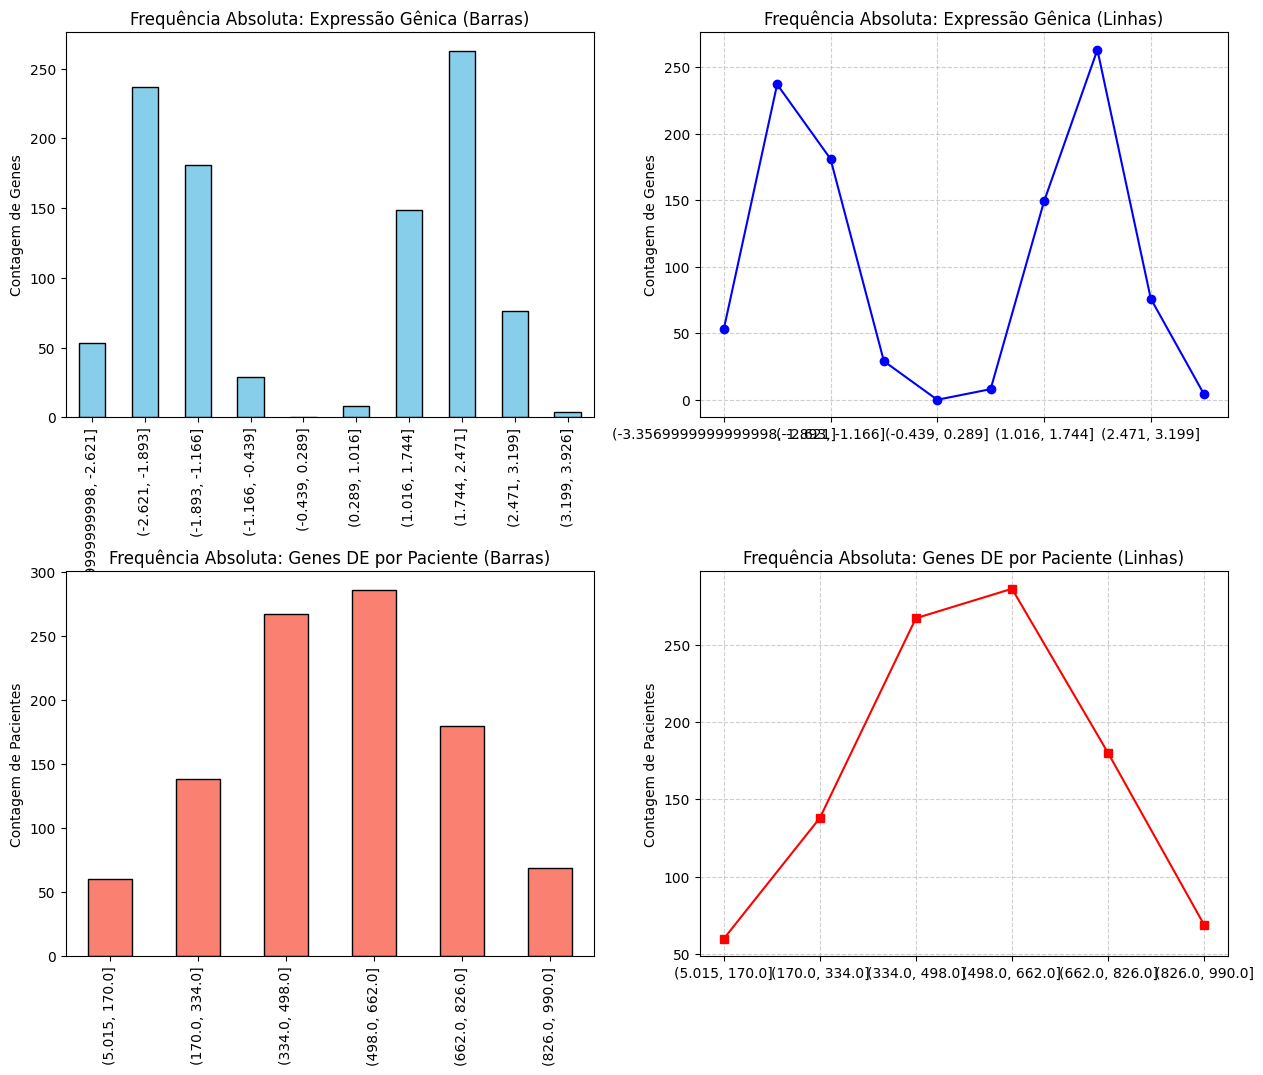

In [51]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.4)

#GRÁFICOS PARA EXERCÍCIO 01
#  Barras
tabela_expressao['Frequência Absoluta (fi)'].plot(kind='bar', ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title("Frequência Absoluta: Expressão Gênica (Barras)")
axes[0, 0].set_ylabel("Contagem de Genes")

#  Linhas
tabela_expressao['Frequência Absoluta (fi)'].plot(kind='line', ax=axes[0, 1], marker='o', color='blue')
axes[0, 1].set_title("Frequência Absoluta: Expressão Gênica (Linhas)")
axes[0, 1].set_ylabel("Contagem de Genes")
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

#GRÁFICOS PARA EXERCÍCIO 02 (Pacientes) 
# Barras
tabela_pacientes['Frequência Absoluta (fi)'].plot(kind='bar', ax=axes[1, 0], color='salmon', edgecolor='black')
axes[1, 0].set_title("Frequência Absoluta: Genes DE por Paciente (Barras)")
axes[1, 0].set_ylabel("Contagem de Pacientes")

# Linhas
tabela_pacientes['Frequência Absoluta (fi)'].plot(kind='line', ax=axes[1, 1], marker='s', color='red')
axes[1, 1].set_title("Frequência Absoluta: Genes DE por Paciente (Linhas)")
axes[1, 1].set_ylabel("Contagem de Pacientes")
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

plt.show()

## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

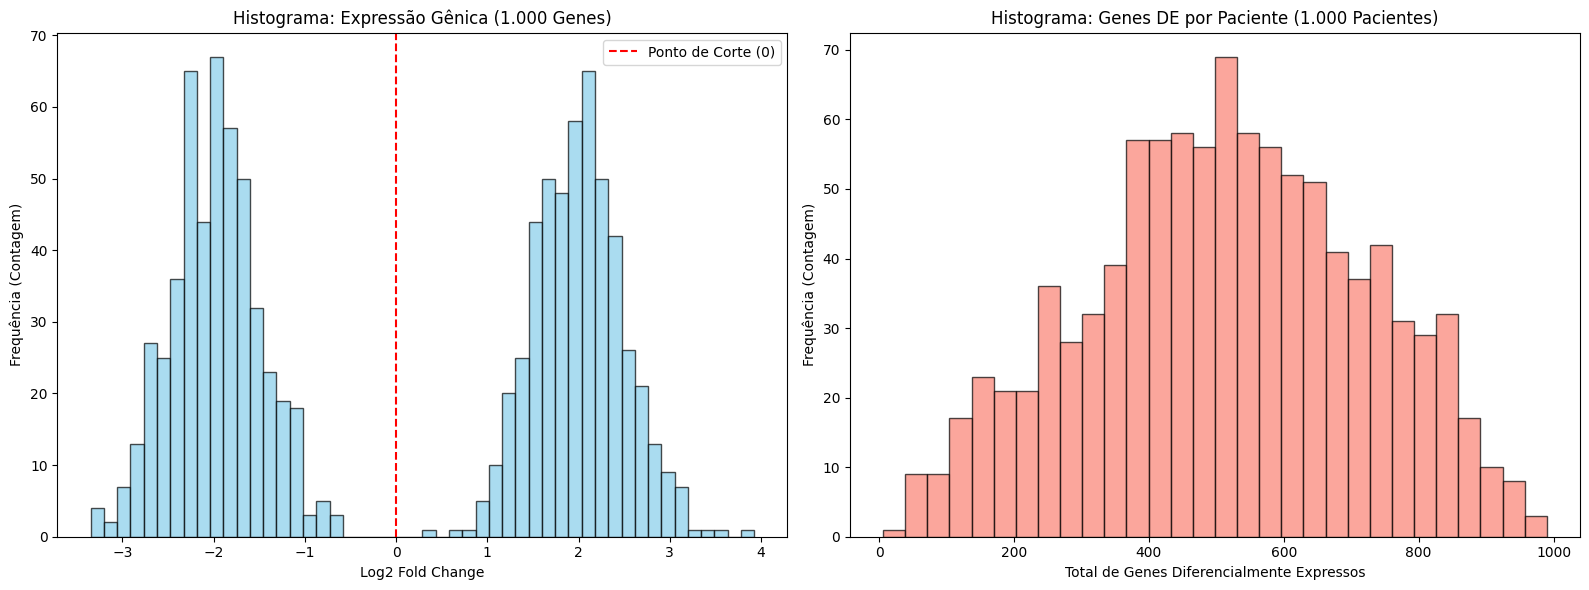

In [ ]:
import matplotlib.pyplot as plt


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

#HISTOGRAMA EX1

ax1.hist(df_expressao['Log2FoldChange'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_title('Histograma: Expressão Gênica (1.000 Genes)')
ax1.set_xlabel('Log2 Fold Change')
ax1.set_ylabel('Frequência (Contagem)')
ax1.axvline(0, color='red', linestyle='--', label='Ponto de Corte (0)')
ax1.legend()

#HISTOGRAMA EX2

ax2.hist(df_pacientes_final['Total_DE'], bins=30, color='salmon', edgecolor='black', alpha=0.7)
ax2.set_title('Histograma: Genes DE por Paciente (1.000 Pacientes)')
ax2.set_xlabel('Total de Genes Diferencialmente Expressos')
ax2.set_ylabel('Frequência (Contagem)')

plt.tight_layout()
plt.show()

## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

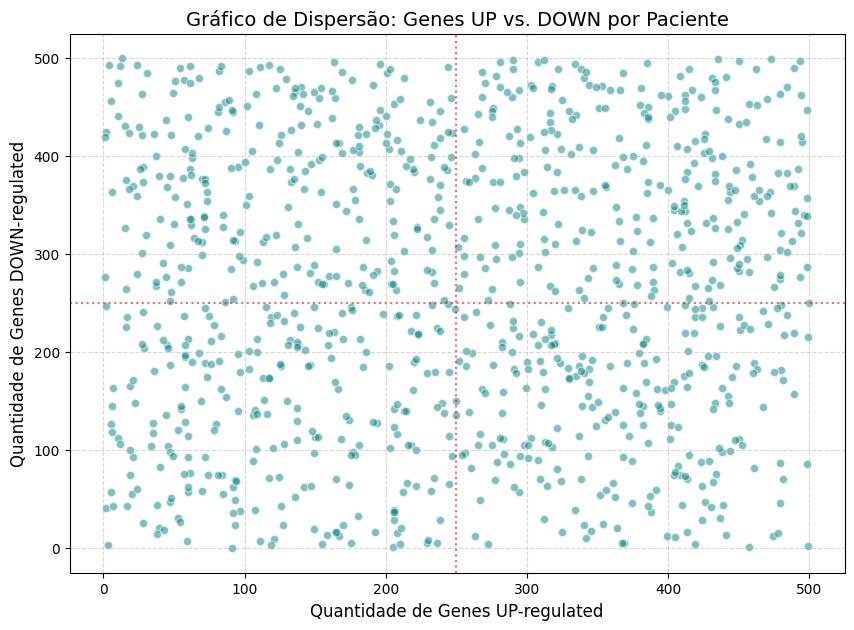

In [ ]:
import matplotlib.pyplot as plt

# Criar a figura
plt.figure(figsize=(10, 7))

# x: Genes_Up, y: Genes_Down
plt.scatter(
    df_pacientes_final['Genes_Up'], 
    df_pacientes_final['Genes_Down'], 
    alpha=0.5,           # Transparência para ver onde os pontos se sobrepõem
    c='teal',            # Cor dos pontos
    edgecolors='white'   # Contorno para destacar pontos individuais
)


plt.title('Gráfico de Dispersão: Genes UP vs. DOWN por Paciente', fontsize=14)
plt.xlabel('Quantidade de Genes UP-regulated', fontsize=12)
plt.ylabel('Quantidade de Genes DOWN-regulated', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# linha de tendência 
plt.axhline(250, color='red', linestyle=':', alpha=0.6, label='Média esperada')
plt.axvline(250, color='red', linestyle=':', alpha=0.6)

plt.show()

## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

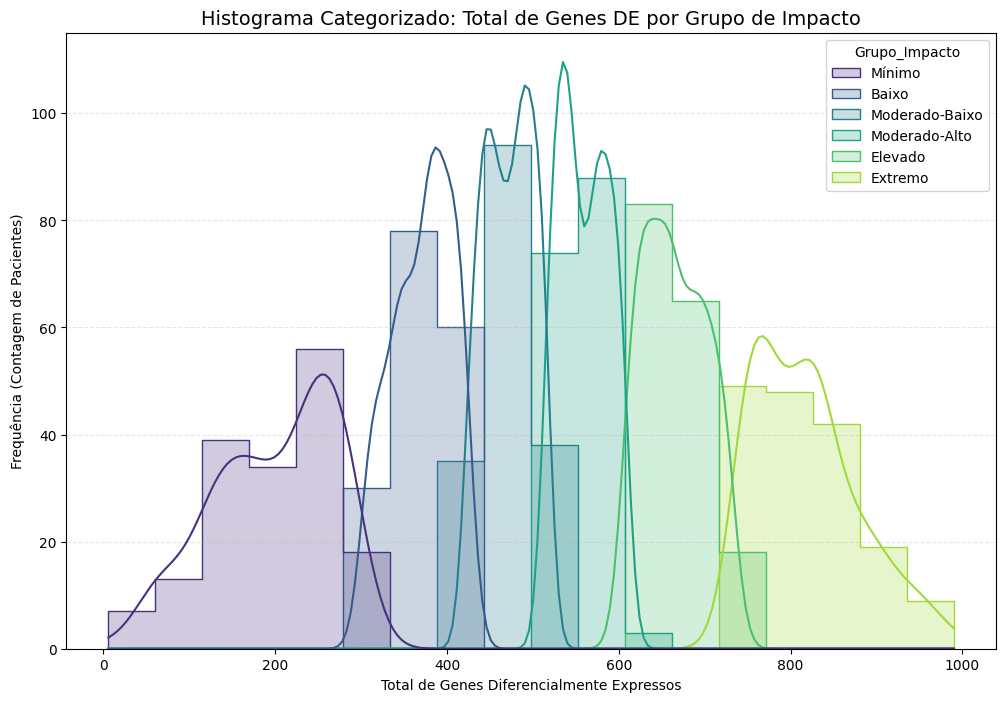

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))


sns.histplot(
    data=df_pacientes_final, 
    x='Total_DE', 
    hue='Grupo_Impacto', 
    kde=True,          
    element="step",    
    palette="viridis"  
)


plt.title('Histograma Categorizado: Total de Genes DE por Grupo de Impacto', fontsize=14)
plt.xlabel('Total de Genes Diferencialmente Expressos')
plt.ylabel('Frequência (Contagem de Pacientes)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

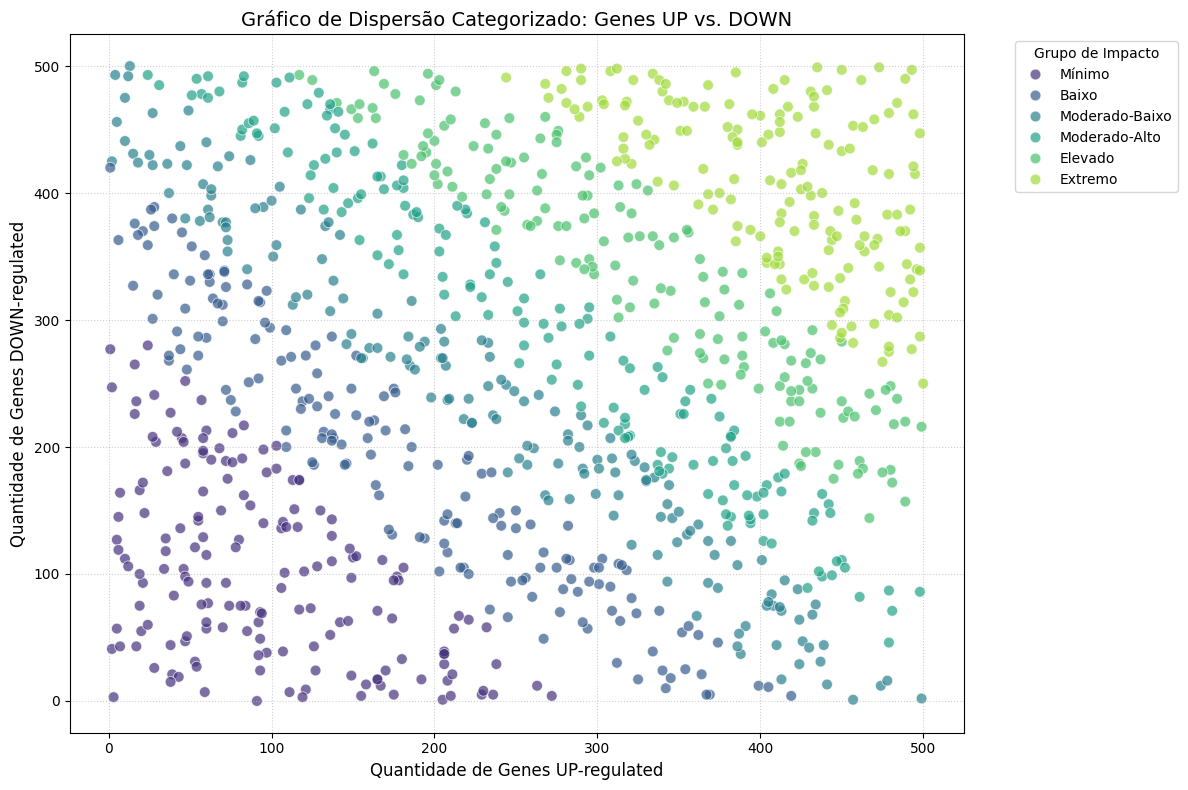

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(12, 8))


sns.scatterplot(
    data=df_pacientes_final, 
    x='Genes_Up', 
    y='Genes_Down', 
    hue='Grupo_Impacto', 
    palette='viridis',   
    alpha=0.7,           
    edgecolor='w',       
    s=60                 
)


plt.title('Gráfico de Dispersão Categorizado: Genes UP vs. DOWN', fontsize=14)
plt.xlabel('Quantidade de Genes UP-regulated', fontsize=12)
plt.ylabel('Quantidade de Genes DOWN-regulated', fontsize=12)
plt.legend(title='Grupo de Impacto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Valor |
| :--- | :---: |
| # de células positivas|discreta|
| % de células positivas|contínua|
| Faixa de pH|ordinal|
| Valor de pH|contínua|
| mol/L|contínua|
| UFC|discreta|
| D.O.|contínua|
| Grupo Sanguíneo|nominal|
| Sorologia|nominal|